In [7]:
import sqlite3
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
import kagglehub
import pandas as pd
# Download latest version
path = kagglehub.dataset_download("parsakh/global-e-commerce-and-supply-chain-database")

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
import sqlite3

conn = sqlite3.connect("ecommerce_supply_chain.db")
cursor = conn.cursor()

In [10]:
data_dir = "/home/codespace/.cache/kagglehub/datasets/parsakh/global-e-commerce-and-supply-chain-database/versions/1"##Paste wherever path appears in the output of the previous cell

tables = {
    "customers": "customers.csv",
    "products": "products.csv",
    "suppliers": "supplier_costs.csv",
    "transactions": "transactions.csv",
    "inventory": "inventory.csv",
}

for table_name, filename in tables.items():
    df = pd.read_csv(os.path.join(data_dir, filename))
    df.to_sql(table_name, conn, if_exists="append", index=False)
    print(f"Loaded {table_name}: {df.shape[0]} rows")

Loaded customers: 8000 rows
Loaded products: 500 rows
Loaded suppliers: 998 rows
Loaded transactions: 100000 rows
Loaded inventory: 500 rows


## 1. Data Pipeline
Raw CSVs (customers, products, suppliers, transactions, inventory) are downloaded via the Kaggle API,
loaded with pandas, and written into a local SQLite database. All subsequent analysis is done with SQL
queries executed against this database rather than in-memory pandas operations, to demonstrate direct
SQL competency.

In [11]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT *
FROM transactions t
"""
transactions_df = pd.read_sql_query(sql_query, conn)

conn.close()

In [12]:
transactions_df.head()

,transaction_id,customer_id,product_id,date,quantity,unit_price_usd,discount_pct,revenue_usd,cost_usd,profit_usd,shipping_cost_usd,channel,payment_method,status,country,category
0,TXN000001,CUST05879,PROD0230,2023-05-15,1,21.66,0.0,21.66,13.00,8.66,7.24,organic_search,paypal,completed,UK,Home & Kitchen
1,TXN000002,CUST00461,PROD0055,2022-08-21,1,188.93,0.0,188.93,85.02,103.91,13.66,social_media,credit_card,completed,USA,Clothing
2,TXN000003,CUST03473,PROD0353,2023-08-28,5,202.21,0.0,1011.05,606.65,404.40,108.68,direct,paypal,completed,France,Home & Kitchen
3,TXN000004,CUST07458,PROD0253,2024-05-31,4,249.76,0.2,799.23,549.48,249.75,0.00,email,bank_transfer,completed,UK,Sports & Outdoors
4,TXN000005,CUST06099,PROD0206,2023-04-22,2,287.63,0.0,575.26,258.86,316.40,9.30,organic_search,credit_card,completed,USA,Clothing


In [13]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT *
FROM customers c
"""
customers_df = pd.read_sql_query(sql_query, conn)

conn.close()

In [14]:
customers_df.head()

,customer_id,first_name,last_name,country,currency,age,gender,registration_date,is_premium,email_verified,email
0,CUST00001,Laura,Brown,UK,GBP,21,F,2020-10-12,0,1,laura.brown0001@email.com
1,CUST00002,Claire,Brown,Australia,AUD,47,M,2020-07-13,1,1,claire.brown0002@email.com
2,CUST00003,Thomas,Allen,Canada,CAD,68,M,2020-06-04,0,1,thomas.allen0003@email.com
3,CUST00004,William,Jackson,France,EUR,59,M,2020-12-12,0,0,william.jackson0004@email.com
4,CUST00005,Nina,Mueller,USA,USD,56,F,2021-10-24,0,1,nina.mueller0005@email.com


## 2. Dataset Overview
Five related tables: **customers** (8,000 rows), **products** (500), **suppliers** (998), 
**transactions** (100,000), and **inventory** (500). Transactions link to customers and products,
letting us join spending behavior against demographic and product attributes.

## 3. Spending by Age Group and Category
Average order value is fairly consistent across age groups, suggesting spend per
transaction isn't strongly age-driven in this dataset — but the top category per age group does differ

In [15]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT  
  case
   when c.age <18 then 'Minor'
   when c.age between 18 and 35 then 'Young Adult'
   when c.age between 36 and 55 then 'Adult'
   when c.age > 55 then 'Elderly'
 END as age_range, 

 AVG(t.revenue_usd) AS average_purchase_amount 

 FROM customers c
JOIN transactions t ON c.customer_id = t.customer_id
JOIN products p ON t.product_id = p.product_id
GROUP BY age_range
ORDER BY average_purchase_amount DESC;"""

top_customers_by_age_df = pd.read_sql_query(sql_query, conn)

conn.close()

In [16]:
top_customers_by_age_df.head()

,age_range,average_purchase_amount
0,Elderly,534.043215
1,Young Adult,531.991876
2,Adult,520.717992


In [17]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT  
  CASE
  when c.is_premium = 1 THEN 'Premium'
  ELSE 'Regular'
  END as customer_type,
 AVG(t.revenue_usd) AS average_purchase_amount,COUNT(DISTINCT c.customer_id) AS customer_count

 FROM customers c
JOIN transactions t ON c.customer_id = t.customer_id
JOIN products p ON t.product_id = p.product_id
GROUP BY customer_type
ORDER BY average_purchase_amount DESC;"""

premium_customers_df = pd.read_sql_query(sql_query, conn)

conn.close()

Text(0, 0.5, 'Customer Count')

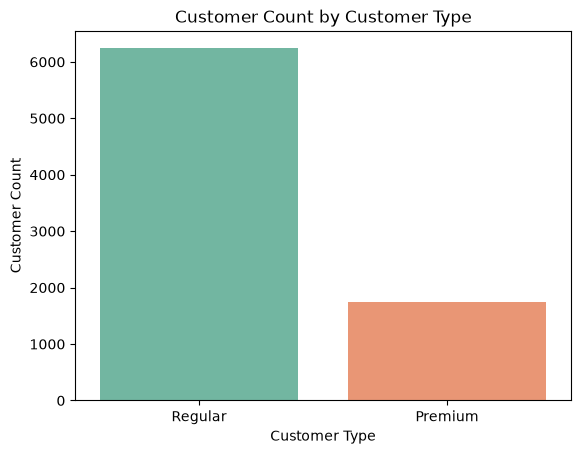

In [18]:
sns.barplot(data=premium_customers_df, x='customer_type', y='customer_count', hue='customer_type',palette='Set2',errorbar=None)
plt.title('Customer Count by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Customer Count')

## 4. Premium vs. Regular Customers
Counterintuitively, **regular customers spend slightly more per order on average  than
premium customers **, despite premium being a smaller group (~$1,700 vs ~6,200 customers).
This suggests premium status in this dataset correlates with a status/subscription tier rather than
purchase intensity.

In [19]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT  
  case
   when c.age <18 then 'Minor'
   when c.age between 18 and 35 then 'Young Adult'
   when c.age between 36 and 55 then 'Adult'
   when c.age > 55 then 'Elderly'
 END as age_range, 
  CASE
  when c.is_premium = 1 THEN 'Premium'
  ELSE 'Regular'
  END as customer_type,
 AVG(t.revenue_usd) AS average_purchase_amount,COUNT(DISTINCT c.customer_id) AS customer_count

 FROM customers c
JOIN transactions t ON c.customer_id = t.customer_id
JOIN products p ON t.product_id = p.product_id
GROUP BY age_range,customer_type
ORDER BY age_range,customer_count DESC;"""

premium_customers_df = pd.read_sql_query(sql_query, conn)

conn.close()

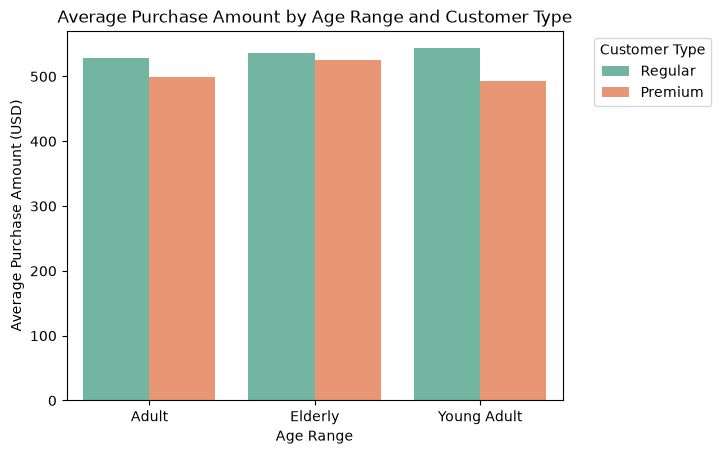

In [20]:
sns.barplot(data=premium_customers_df, x='age_range', y='average_purchase_amount', hue='customer_type',palette='Set2')
plt.title('Average Purchase Amount by Age Range and Customer Type')
plt.xlabel('Age Range')
plt.ylabel('Average Purchase Amount (USD)')
plt.legend(title='Customer Type', bbox_to_anchor=(1.05, 1), loc='upper left')

## 5. High-Value Customer Identification (RFM-style)
Ranking customers by purchase frequency surfaces a small group of extreme outliers — the top customer
(CUST01713) has 15039 completed transactions and $6861756.33 in lifetime revenue, roughly 1.5x the next
highest. Only 1 of the top 10 most frequent buyers is currently flagged `is_premium`, suggesting the
premium flag under-captures actual high-value customers and could be a candidate for a
recency/frequency/monetary-based re-segmentation instead of the existing binary flag.

In [21]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT
    c.customer_id,
    julianday('2024-12-31') - julianday(MAX(t.date)) AS recency_days,
    COUNT(t.transaction_id) AS frequency,
    SUM(t.revenue_usd) AS monetary,c.is_premium,c.email,c.registration_date
FROM customers c
JOIN transactions t ON c.customer_id = t.customer_id
WHERE t.status = 'completed'
GROUP BY c.customer_id
ORDER BY frequency DESC
LIMIT 10;"""

rfm_df = pd.read_sql_query(sql_query, conn)

conn.close()

In [22]:
rfm_df.head(10)

,customer_id,recency_days,frequency,monetary,is_premium,email,registration_date
0,CUST01713,0.0,26736,12198677.92,1,elena.mueller1713@email.com,2020-05-16
1,CUST01068,0.0,14016,7883257.28,0,sara.rossi1068@email.com,2020-09-16
2,CUST05248,3.0,12896,6852426.24,0,david.harris5248@email.com,2021-04-17
3,CUST03000,4.0,11936,6770070.56,0,james.jackson3000@email.com,2021-01-21
4,CUST00785,0.0,9664,6130182.08,0,sara.rossi0785@email.com,2021-02-16
5,CUST01593,0.0,6800,3682264.64,0,anna.dubois1593@email.com,2020-03-19
6,CUST04788,0.0,6096,3529151.36,0,robert.jackson4788@email.com,2020-02-09
7,CUST03425,0.0,5168,2904335.36,0,james.young3425@email.com,2021-11-18
8,CUST06388,3.0,4896,2681436.64,0,daniel.johnson6388@email.com,2020-06-20
9,CUST07467,0.0,4864,2446329.12,0,sara.harris7467@email.com,2021-09-15


## 6. Performance by Country
The USA leads on every metric, roughly double the UK,
the next largest market. The top 5 countries (USA, UK, Germany, France, Canada) account for the large
majority of both profit and volume, suggesting expansion or retention efforts are best concentrated
there rather than spread evenly across all represented countries.

In [23]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT country, 
COUNT(DISTINCT customer_id) AS customer_count,
SUM(profit_usd) AS total_profit,
SUM(quantity) as Total_Units_Sold


FROM transactions t
WHERE status = 'completed'
GROUP BY country
ORDER BY customer_count DESC

LIMIT 10;"""

country_df = pd.read_sql_query(sql_query, conn)

conn.close()

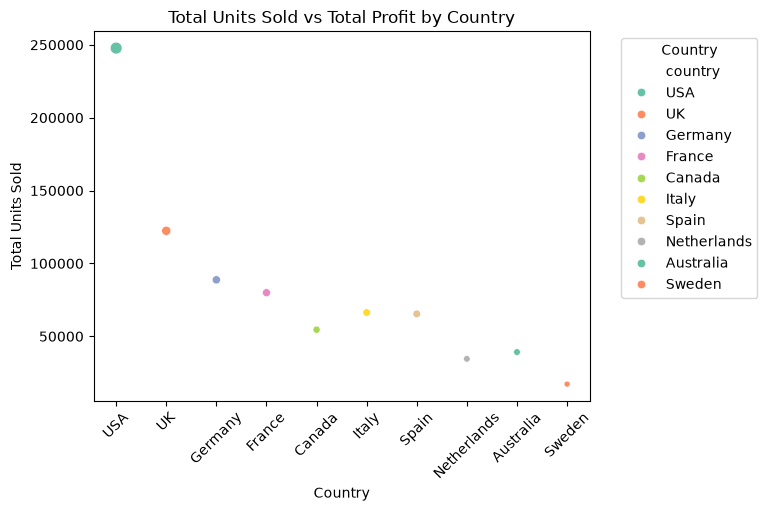

In [24]:
ax=sns.scatterplot(data=country_df, x='country', y='Total_Units_Sold', size='total_profit', hue='country', palette='Set2')
plt.title('Total Units Sold vs Total Profit by Country')
plt.xlabel('Country')
plt.ylabel('Total Units Sold')
handles, labels = ax.get_legend_handles_labels()
if "total_profit" in labels:
    cutoff = labels.index("total_profit")
    handles = handles[:cutoff]
    labels = labels[:cutoff]
    plt.legend(
    handles=handles,
    labels=labels,
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.xticks(rotation=45)
plt.show()

## 7. Seasonality
Revenue is strongly seasonal: December  is the peak month, roughly 2.5x February, the lowest
. Revenue climbs steadily from Q1 through Q4, consistent with a holiday-driven shopping pattern
rather than random month-to-month noise.

In [25]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT 
    strftime('%m', date) AS month,
    SUM(revenue_usd) AS total_revenue,
    SUM(profit_usd) AS total_profit,
    SUM(quantity) AS total_units_sold,
    COUNT(DISTINCT customer_id) AS customer_count

FROM transactions
WHERE status = 'completed'
GROUP BY month
ORDER BY month, total_revenue DESC
LIMIT 12;"""

best_months_df = pd.read_sql_query(sql_query, conn)

conn.close()

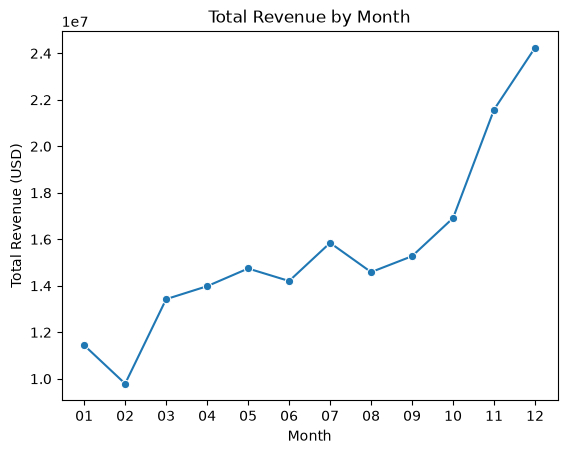

In [26]:
sns.lineplot(data=best_months_df, x='month', y='total_revenue', marker='o')
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.show()

In [27]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """
SELECT 
    p.brand AS brand_name,
   ROUND(SUM(t.revenue_usd), 2) AS brand_revenue,
    SUM(t.quantity) AS brand_units,
    SUM(ROUND(SUM(t.revenue_usd), 2)) OVER () AS grand_total_revenue,
    ROUND(SUM(t.revenue_usd) * 100.0 / SUM(ROUND(SUM(t.revenue_usd), 2)) OVER (), 2) AS pct_of_total_revenue
FROM transactions t
JOIN products p ON t.product_id = p.product_id
WHERE t.status = 'completed'
GROUP BY p.brand
ORDER BY brand_revenue DESC;
"""

brand_share_df = pd.read_sql_query(sql_query, conn)

## 8. Brand Market Share
Breaking down revenue by brand shows how concentrated the market is at the top — the leading brand's
share, visualized here as both unit volume and percentage of total revenue, indicates whether one brand
dominates or the market is fragmented across many similarly-sized competitors.

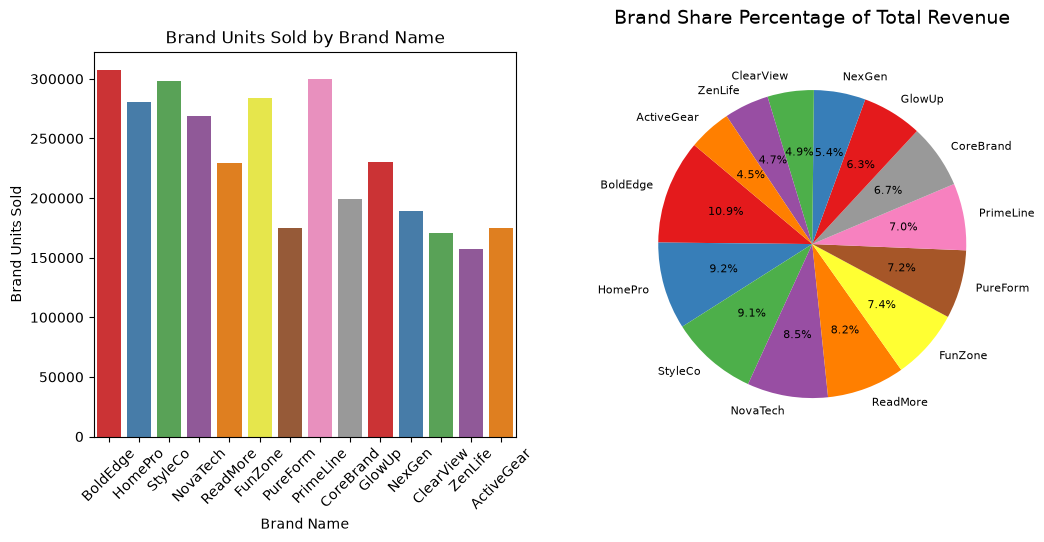

<Figure size 640x480 with 0 Axes>

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


ax2 = sns.barplot(
    data=brand_share_df,
    x="brand_name",
    y="brand_units",
    hue="brand_name",
    palette="Set1",
    ax=ax1,
    legend=False,
)
ax2.set_title("Brand Units Sold by Brand Name")
ax2.set_xlabel("Brand Name")
ax2.set_ylabel("Brand Units Sold")
ax2.tick_params(axis="x", rotation=45)


# 1. Choose a Seaborn color palette and extract the colors
colors = sns.color_palette("Set1", len(brand_share_df))

# 3. Create the pie chart using Matplotlib
ax2=plt.pie(
    x=brand_share_df["pct_of_total_revenue"],  # Numeric values for slices
    labels=brand_share_df["brand_name"],  # Text labels for slices
    colors=colors,  # Applies your Seaborn colors
    autopct="%1.1f%%",  # Displays percentage text format inside slices
    startangle=140,  # Rotates the starting position for better look
    textprops={"fontsize": 8},# Adjusts text size
      
)
palette = sns.color_palette("Set1", len(brand_share_df))
# 4. Add title and display
plt.title("Brand Share Percentage of Total Revenue", fontsize=14, pad=20)
plt.show()

plt.tight_layout()
plt.show()


## 9. Brand Performance Over Time
Tracking each brand's monthly revenue reveals whether brand rankings are stable year-round or whether
different brands lead during different seasons. A brand that holds its rank in both peak (Q4) and
off-peak months is a more reliable long-term bet for inventory planning than one whose popularity is
purely holiday-driven.

In [29]:
sql_query = """
SELECT 
    p.brand AS brand_name,
    strftime('%m', t.date) AS month,
    ROUND(SUM(t.revenue_usd), 2) AS brand_revenue,
    SUM(t.quantity) AS brand_units
FROM transactions t
JOIN products p ON t.product_id = p.product_id
WHERE t.status = 'completed'
GROUP BY p.brand, month
ORDER BY month ASC, brand_revenue DESC;
"""

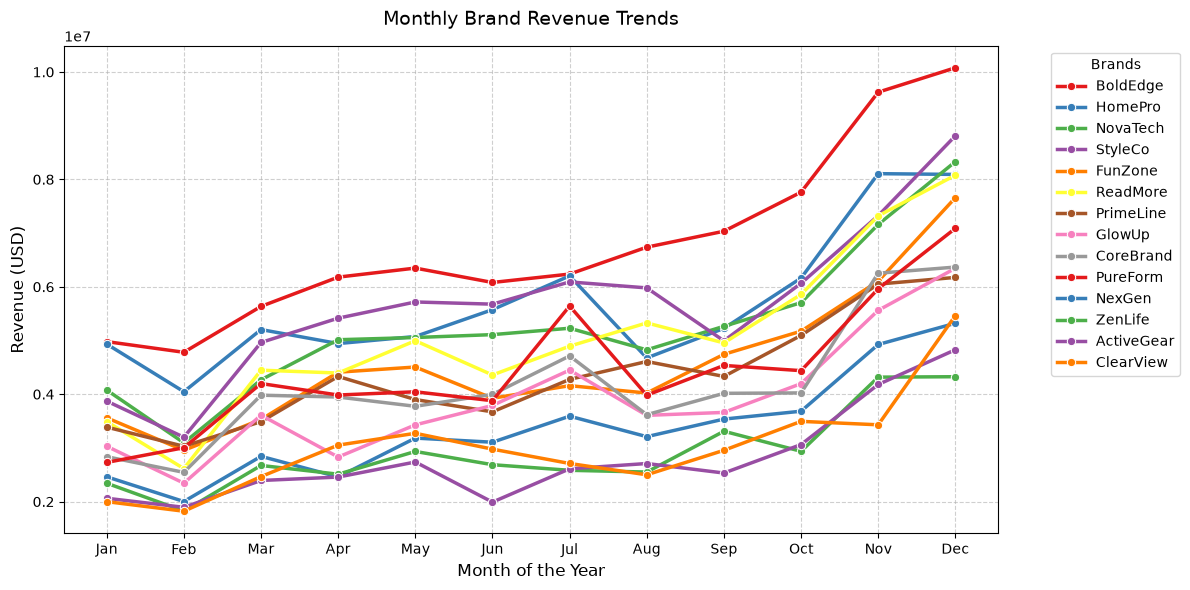

In [30]:
# Load the structured time-series data
brand_monthly_df = pd.read_sql_query(sql_query, conn)

# 2. Build the line chart using Seaborn
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=brand_monthly_df,
    x="month",  # X-axis tracks the months
    y="brand_revenue",  # Y-axis tracks the sales revenue
    hue="brand_name",  # Creates a distinct colored line for each brand
    palette="Set1",  # Applies your high-contrast Set1 color scheme
    marker="o",  # Adds visible dot indicators on every month's data point
    linewidth=2.5,
)

# 3. Clean and polish the axis layout
plt.title("Monthly Brand Revenue Trends", fontsize=14, pad=15)
plt.xlabel("Month of the Year", fontsize=12)
plt.ylabel("Revenue (USD)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)  # Adds a clean background grid for tracking lines

plt.xticks(
    ticks=range(len(brand_monthly_df["month"].unique())),
    labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"][:len(brand_monthly_df["month"].unique())]
)
plt.legend(title="Brands", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()


## 10. Who Buys BoldEdge?
Looking at BoldEdge's buyer base by age range shows whether its appeal skews toward a specific
demographic or is broadly distributed. Adults lead the quantity of unist bought while the revenue is the same as elder people.

In [31]:
sql_query = """
SELECT 
    CASE
        WHEN c.age < 18 THEN 'Minor'
        WHEN c.age BETWEEN 18 AND 35 THEN 'Young Adult'
        WHEN c.age BETWEEN 36 AND 55 THEN 'Adult'
        ELSE 'Elderly'
    END AS age_range,
    COUNT(DISTINCT c.customer_id) AS num_customers,
    SUM(t.revenue_usd) AS revenue,
    SUM(t.profit_usd) AS profit,
    SUM(t.quantity) AS units_sold
FROM transactions t
JOIN customers c ON t.customer_id = c.customer_id
JOIN products p ON t.product_id = p.product_id
WHERE p.brand = 'BoldEdge'
    
GROUP BY age_range
ORDER BY num_customers DESC;
"""

age_profile_df = pd.read_sql_query(sql_query, conn)

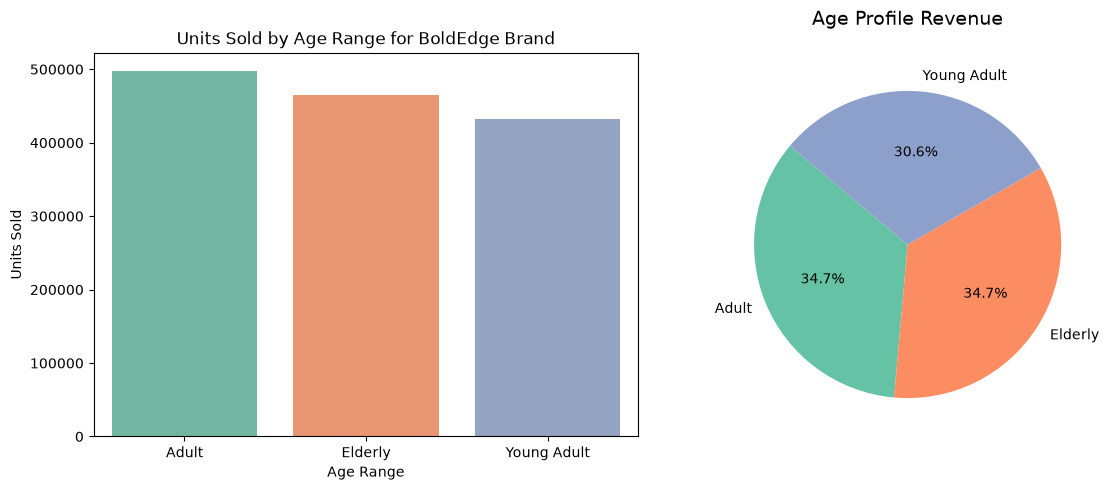

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1=sns.barplot(data=age_profile_df, x='age_range', y='units_sold', hue='age_range', palette='Set2', errorbar=None,ax=ax1)
ax1.set_title('Units Sold by Age Range for BoldEdge Brand')
ax1.set_xlabel('Age Range')
ax1.set_ylabel('Units Sold')
colors = sns.color_palette("Set2", len(brand_share_df))

# 2. Set up the figure canvas

# 3. Create the pie chart using Matplotlib
ax2=plt.pie(
    x=age_profile_df["revenue"],  # Numeric values for slices
    labels=age_profile_df["age_range"],  # Text labels for slices
    colors=colors,  # Applies your Seaborn colors
    autopct="%1.1f%%",  # Displays percentage text format inside slices
    startangle=140,  # Rotates the starting position for better look
    textprops={"fontsize": 10},# Adjusts text size
      
)

palette = sns.color_palette("Set1", len(brand_share_df))
# 4. Add title and display
plt.title("Age Profile Revenue", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## 11. Is BoldEdge's Popularity Global or Country-Specific?
Since BoldEdge led both the country and brand rankings independently, this checks whether that's one
finding or two — breaking brand revenue share down within each country shows whether BoldEdge's strength
is broad-based or concentrated in a specific market (e.g. the USA). Bold Edge seeems to be leading brand in most of the countries along the chart.Only competing in France and Canada with HomePro, likely because of a niche(both countries speak French)

In [33]:
sql_query = """
SELECT
    t.country,
    p.brand,
    SUM(t.revenue_usd) AS brand_revenue,
    SUM(SUM(t.revenue_usd)) OVER (PARTITION BY t.country) AS country_total_revenue,
    ROUND(SUM(t.revenue_usd) * 100.0 / SUM(SUM(t.revenue_usd)) OVER (PARTITION BY t.country), 2) AS pct_of_country_revenue
FROM transactions t
JOIN products p ON t.product_id = p.product_id
WHERE t.status = 'completed'
GROUP BY t.country, p.brand
ORDER BY t.country, pct_of_country_revenue DESC;"""

country_brand_df = pd.read_sql_query(sql_query, conn)

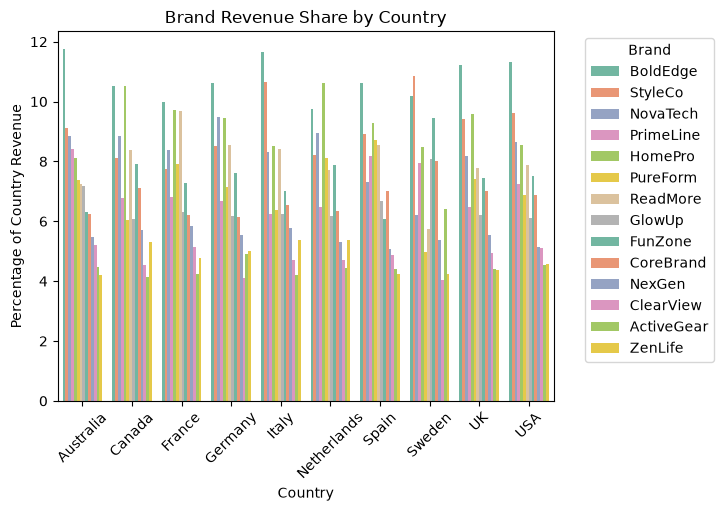

In [34]:
sns.barplot(data=country_brand_df, x='country', y='pct_of_country_revenue', hue='brand', palette='Set2')
plt.title('Brand Revenue Share by Country')
plt.xlabel('Country')
plt.ylabel('Percentage of Country Revenue')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()  

## Stockout Risk: Sell-Through Ratio by Product

Rather than comparing total units sold against raw stock count across all BoldEdge products at once (which
mixes unrelated SKUs that happen to share a stock level), this looks at each product individually: units
sold divided by current stock on hand. A high ratio means a product has sold heavily relative to what's
left in inventory — a stronger restock signal than sales volume or stock level alone.

The top 15 products by this ratio are the clearest restocking priorities within the BoldEdge line. Any
product at or near a ratio driven by zero current stock should be treated as an immediate out-of-stock
risk rather than just "high demand."

In [123]:
sql_query = """SELECT
    p.name,
    i.stock_units AS stock_level,
    SUM(t.quantity) AS units_sold,
    ROUND(SUM(t.quantity) * 1.0 / NULLIF(i.stock_units, 0), 2) AS sell_through_ratio
FROM products p
JOIN inventory i ON p.product_id = i.product_id
JOIN transactions t ON p.product_id = t.product_id
WHERE p.brand = 'BoldEdge' AND t.status = 'completed'
GROUP BY p.name, i.stock_units
ORDER BY sell_through_ratio DESC;"""

inventory_df = pd.read_sql_query(sql_query, conn)

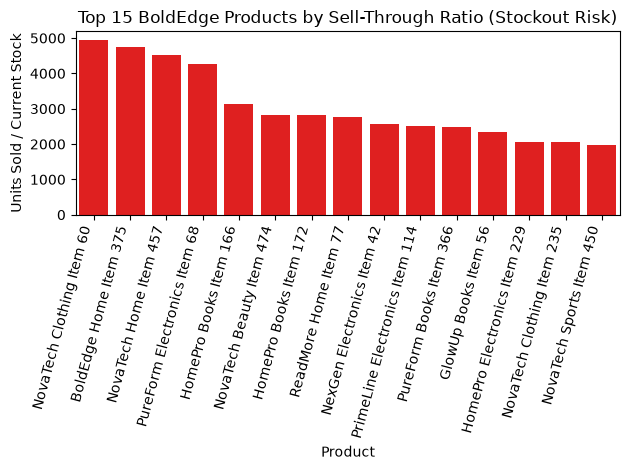

In [124]:
top_risk = inventory_df.sort_values("sell_through_ratio", ascending=False).head(15)

sns.barplot(data=top_risk, x="name", y="sell_through_ratio", color="red")
plt.title("Top 15 BoldEdge Products by Sell-Through Ratio (Stockout Risk)")
plt.xlabel("Product")
plt.ylabel("Units Sold / Current Stock")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

## 16. Conclusions & Next Steps

This analysis moved from broad customer segmentation toward increasingly specific, supply-chain-relevant
questions. Key findings:

- **Purchase frequency is a stronger indicator of customer value than the existing premium flag** — the
  top customer by frequency (1,671 transactions, $762K lifetime revenue) isn't even flagged `is_premium`.
- **Revenue is highly seasonal and geographically concentrated**, peaking in December (~2.5x the February
  low) and led heavily by the USA.
- **BoldEdge is the top brand overall**, and follow-up analysis checked whether that popularity holds
  within each country and across the brand's customer age profile.
- **An initial stockout-risk query was corrected mid-analysis**: grouping by raw stock level mixed
  unrelated products that happened to share a stock count, producing a misleading chart. Re-running the
  analysis at the individual product level with a sell-through ratio (units sold ÷ current stock)
  produced a defensible restocking priority list instead.

**Not yet covered**: supplier cost data (`suppliers` table). Joining supplier cost to product margin —
is BoldEdge's popularity also profitable, or high-volume but thin-margin? — remains the one part of the
"supply chain" half of this dataset this analysis hasn't touched.